In [24]:
# !kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset -p ../data --unzip

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
  0%|                                                | 0.00/195M [00:00<?, ?B/s]
100%|████████████████████████████████████████| 195M/195M [00:00<00:00, 3.47GB/s]


In [ ]:
from datasets import Dataset, DatasetDict, Features, Value, Image as HfImage
from PIL import Image as PilImage
import numpy as np
import os

In [ ]:
base_dir = "../data/Dataset_BUSI_with_GT/"

records = []
for label in ["benign", "malignant", "normal"]:
    folder = os.path.join(base_dir, label)
    for file in os.listdir(folder):
        if not file.endswith(".png") or "mask" in file:
            continue

        img_path = os.path.join(folder, file)

        # Find all masks for this image
        base_name = file.replace(".png", "")
        mask_files = [
            f for f in os.listdir(folder) if f.startswith(base_name + "_mask")
        ]

        if mask_files:
            masks = []
            for m in mask_files:
                mask_img = np.array(PilImage.open(os.path.join(folder, m)).convert("L"))
                masks.append(mask_img > 0)

            merged_mask = np.any(masks, axis=0).astype(np.uint8) * 255
            conditioning_image = PilImage.fromarray(merged_mask)

            # save merged mask to temporary memoryless object (png bytes)
            conditioning_image_path = os.path.join(folder, f"{base_name}_mask_temp.png")
            conditioning_image.save(conditioning_image_path)
        else:
            conditioning_image_path = None

        records.append(
            {
                "image": img_path,  # just the path
                "conditioning_image": conditioning_image_path,  # path to merged mask
                "caption": label,
            }
        )

# Define features so Hugging Face knows how to decode them
features = Features(
    {"image": HfImage(), "conditioning_image": HfImage(), "caption": Value("string")}
)

hf_dataset = Dataset.from_list(records, features=features)
print(hf_dataset)

Dataset({
    features: ['image', 'conditioning_image', 'caption'],
    num_rows: 780
})


In [15]:
hf = load_dataset("Amss007/ultrasound_dataset_v3_1", cache_dir="../data")
print(hf)

DatasetDict({
    train: Dataset({
        features: ['image', 'conditioning_image', 'caption'],
        num_rows: 3985
    })
})


In [16]:
features = Features(
    {"image": Image(), "conditioning_image": Image(), "caption": Value("string")}
)

# Cast Kaggle dataset
kaggle_dataset = kaggle_dataset.cast(features)

hf_dataset = hf["train"]  # flatten to Dataset
hf_dataset = hf_dataset.cast(features)

merged_dataset = concatenate_datasets([hf_dataset, kaggle_dataset])

print(merged_dataset)

Casting the dataset:   0%|          | 0/780 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'conditioning_image', 'caption'],
    num_rows: 4765
})


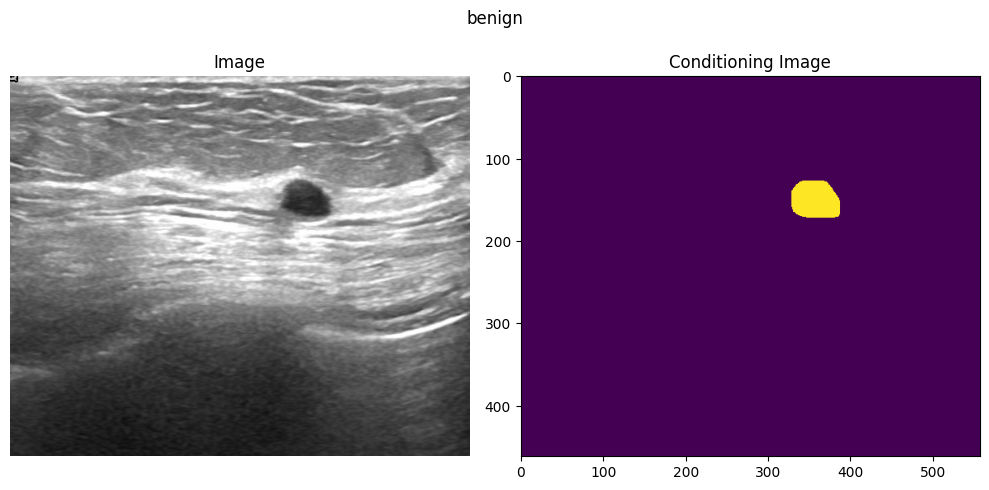

In [22]:
import matplotlib.pyplot as plt

example = kaggle_dataset[53]
image = example["image"]  # PIL Image
conditioning_image = example["conditioning_image"]  # PIL Image or None
caption = example["caption"]  # String

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(image)
axs[0].set_title("Image")
axs[0].axis("off")

if conditioning_image is not None:
    axs[1].imshow(conditioning_image)
    axs[1].set_title("Conditioning Image")
else:
    axs[1].set_visible(False)

plt.suptitle(caption)
plt.tight_layout()